
# Does Proactive Credit Counseling Actually Reduce Loan Default?
### A Banking-Industry project applying *Graphical Causal Models* (Chapter 3, Facure — *Causal Inference in Python*)

**The business question:** A bank runs a **Proactive Credit Counseling** program — early-alert
customers (people showing early signs of financial strain: rising utilization, a missed payment,
etc.) get invited to a free session with a credit counselor who helps them build a repayment
budget. The risk team wants to know:

> *Does the counseling program actually reduce the probability that a customer defaults on their
> loan within the next 12 months — or does it just look that way (or even look harmful) because
> the customers who get invited are already the riskiest ones?*

This mirrors the chapter's "manager training → team engagement" and "consultancy → firm
performance" examples almost exactly, but banking adds two extra wrinkles we'll use as a chance
to go one level deeper into the toolkit:

1. **Confounding** — riskier customers are the ones targeted for counseling, so a naive
   comparison will be badly biased (possibly making a *helpful* program look *harmful*).
2. **Mediation** — part of the program's effect on default happens *through* a measurable
   mid-point (customers adopting better budgeting habits). We'll show why **controlling for
   that mediator is a mistake** if what you want is the *total* effect of the program — the
   same trap as the book's gender-pay-gap / seniority example.
3. **Selection bias (collider)** — compliance manually reviews a *subset* of accounts (both
   enrolled accounts and defaulted accounts get flagged for review). Restricting analysis to
   "reviewed accounts only" reopens bias, exactly like the NPS-survey example — and this time
   we'll see it can even flip the sign of the estimated effect.

> As before, we simulate data with a **known ground-truth causal effect** so we can check,
> at the end, whether each technique recovers the truth — including simulating actual
> **potential outcomes** (the "godlike powers" trick from the book) to compute that ground truth.


## Step 0 — Setup

In [1]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import graphviz as gr
import statsmodels.formula.api as smf

np.random.seed(7)
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110



## Step 1 — Write down our causal story first

Before looking at any data, we encode our beliefs:

- **`prior_risk`** (a 0–1 score built from missed-payment history, utilization trend, etc.):
  drives *both* who gets invited into counseling (the bank targets at-risk customers) *and*
  the baseline odds of default. This is our **confounder**.
- **`enrolled`** (took part in the counseling program) has:
  - a **direct effect** on default (e.g., payment reminders, renegotiated terms), and
  - an **indirect / mediated effect**, by making customers more likely to **`adopted_budgeting`**
    (a measurable behavior change), which itself reduces default.
- **`reviewed`**: compliance flags accounts for manual review. Both `enrolled` (program
  accounts get audited) and `default` (defaults get audited) increase the chance of review —
  a classic **collider**.


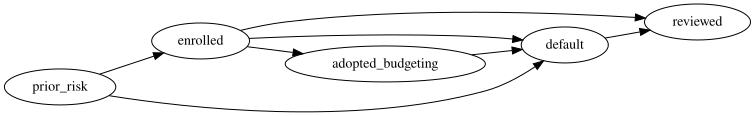

In [2]:

g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.attr('node', shape='ellipse')

g.edge("prior_risk", "enrolled")
g.edge("prior_risk", "default")
g.edge("enrolled", "adopted_budgeting")          # part of the causal story (mediator)
g.edge("adopted_budgeting", "default")           # indirect causal path
g.edge("enrolled", "default")                    # direct causal path
g.edge("enrolled", "reviewed")
g.edge("default", "reviewed")                    # collider!

g



**Reading the graph:**

- `prior_risk → enrolled` and `prior_risk → default`: a **fork** (confounder). This alone
  will bias a naive comparison — and notice the direction: since the *riskiest* customers are the
  ones enrolled, this confounding will tend to make the program look **worse than it is** (the
  opposite of the previous "Premium Support" project, where confounding made it look better).
- `enrolled → adopted_budgeting → default`: a **chain**. This is a real causal path — part of
  *how* the program works — and should **not** be blocked.
- `enrolled → default`: the direct effect (independent of budgeting habits).
- `enrolled → reviewed ← default`: an **immorality / collider**. Restricting the analysis to
  reviewed accounts opens a noncausal path between `enrolled` and `default`.



## Step 2 — Simulate data, including *potential outcomes*, so we know the ground truth

Just like the book's NPS example ("pretend you can see into the world of counterfactual
outcomes"), we'll simulate each customer's default outcome **both** under `enrolled = 1` and
`enrolled = 0`, using the same underlying noise. That lets us compute the *true* average
treatment effect directly — something we could never do with real data — so we can grade our
causal-inference toolkit at the end.

**Ground truth we're baking in:**
- Direct effect of enrollment on default probability: **−7 points** (`DIRECT_EFFECT = 0.07`)
- Effect of adopting budgeting habits on default probability: **−16 points**
  (`MEDIATOR_EFFECT = 0.16`)
- Enrollment increases the probability of adopting budgeting habits by roughly **+55 points**

So the **total** effect of the program (direct + mediated) should come out to roughly
`-0.07 - 0.16 * 0.55 ≈ -0.16`, i.e. **about a 16-point reduction in default risk**.


In [3]:

n = 25_000
DIRECT_EFFECT = 0.07
MEDIATOR_EFFECT = 0.16

# prior_risk: 0 = pristine credit history, 1 = clear signs of distress
prior_risk = np.random.beta(2, 2, n)

# Fixed uniform draws let us build consistent potential outcomes under different
# hypothetical values of `enrolled`, the same underlying "luck" either way.
u_budget = np.random.uniform(0, 1, n)
u_default = np.random.uniform(0, 1, n)

def budgeting_given(enrolled_arr):
    p = np.clip(0.10 + 0.55 * enrolled_arr + 0.05 * (1 - prior_risk), 0.02, 0.98)
    return (u_budget < p).astype(int)

def default_given(enrolled_arr, budgeting_arr):
    p = np.clip(
        0.05 + 0.55 * prior_risk - DIRECT_EFFECT * enrolled_arr - MEDIATOR_EFFECT * budgeting_arr,
        0.01, 0.95
    )
    return (u_default < p).astype(int)

# --- Potential outcomes (the "godlike powers" trick) ---
budgeting_1, budgeting_0 = budgeting_given(np.ones(n)), budgeting_given(np.zeros(n))
default_1 = default_given(np.ones(n), budgeting_1)
default_0 = default_given(np.zeros(n), budgeting_0)

TRUE_ATE = (default_1 - default_0).mean()
print(f"TRUE total causal effect of enrollment on default probability: {TRUE_ATE:+.3f}")


TRUE total causal effect of enrollment on default probability: -0.144


Now let's build the **observed** dataset — the only thing a real analyst would ever see.

In [4]:

# The bank targets riskier customers for the program (this is the confounding mechanism)
p_enroll = 1 / (1 + np.exp(-(4 * prior_risk - 2)))
enrolled = np.random.binomial(1, p_enroll)

# Realized mediator and outcome, using the SAME noise draws as the potential outcomes above,
# consistent with the `enrolled` value each customer actually received
adopted_budgeting = budgeting_given(enrolled)
default = default_given(enrolled, adopted_budgeting)

# Compliance review: enrolled accounts and defaulted accounts are more likely to be reviewed
p_review = 1 / (1 + np.exp(-(-2 + 2.5 * enrolled + 3 * default)))
reviewed = np.random.binomial(1, p_review)

df = pd.DataFrame({
    "prior_risk": prior_risk,
    "enrolled": enrolled,
    "adopted_budgeting": adopted_budgeting,
    "default": default,
    "reviewed": reviewed,
})

df.head()


,prior_risk,enrolled,adopted_budgeting,default,reviewed
0,0.574,0,0,0,0
1,0.332,0,0,1,1
2,0.516,0,0,0,0
3,0.352,0,1,0,0
4,0.275,0,0,0,0



## Step 3 — The naive (wrong) comparison

Risk team's first instinct: just compare default rates between enrolled and non-enrolled
customers.


In [5]:

naive_effect = (
    df.query("enrolled == 1")["default"].mean()
    - df.query("enrolled == 0")["default"].mean()
)
print(f"Naive difference in default rate: {naive_effect:+.3f}")
print(f"True total causal effect:         {TRUE_ATE:+.3f}")
print(f"Bias in the naive estimate:       {naive_effect - TRUE_ATE:+.3f}")


Naive difference in default rate: -0.051
True total causal effect:         -0.144
Bias in the naive estimate:       +0.094



Because the bank deliberately enrolls its *riskiest* customers, the naive comparison makes the
program look far less helpful than it actually is — the raw numbers might even make a real
risk analyst conclude the program **increases** default risk. This is exactly the danger the
book warns about: confounding bias can point in *either* direction, and it will always favor
whatever mechanism assigned the treatment in the first place.



## Step 4 — Confirm the structure with d-separation


In [6]:

model = nx.DiGraph([
    ("prior_risk", "enrolled"),
    ("prior_risk", "default"),
    ("enrolled", "adopted_budgeting"),
    ("adopted_budgeting", "default"),
    ("enrolled", "default"),
    ("enrolled", "reviewed"),
    ("default", "reviewed"),
])

try:
    def dependent(g, x, y, z=set()):
        return not nx.is_d_separator(g, {x}, {y}, set(z))
except AttributeError:
    def dependent(g, x, y, z=set()):
        return not nx.d_separated(g, {x}, {y}, set(z))

print("enrolled / default dependent (no conditioning)?             ", dependent(model, "enrolled", "default"))
print("enrolled / default dependent, given prior_risk?              ", dependent(model, "enrolled", "default", {"prior_risk"}))
print("enrolled / default dependent, given prior_risk + budgeting?  ", dependent(model, "enrolled", "default", {"prior_risk", "adopted_budgeting"}))


enrolled / default dependent (no conditioning)?              True
enrolled / default dependent, given prior_risk?               True
enrolled / default dependent, given prior_risk + budgeting?   True



All three come back `True` — which makes sense, since there's *always* at least one open causal
path left in each case. The important distinction networkx can't tell you on its own: **which**
of those remaining open paths are causal vs. noncausal. That's where the "severed graph" trick
comes back in.


In [7]:

# Delete BOTH causal edges (direct AND mediated) to isolate purely noncausal paths
severed = nx.DiGraph([
    ("prior_risk", "enrolled"),
    ("prior_risk", "default"),
    ("enrolled", "adopted_budgeting"),
    # ("adopted_budgeting", "default"),  <-- mediated causal edge removed
    # ("enrolled", "default"),           <-- direct causal edge removed
    ("enrolled", "reviewed"),
    ("default", "reviewed"),
])

print("With BOTH causal edges removed:")
print("  Still dependent, no adjustment?                 ",
      dependent(severed, "enrolled", "default"), " <- backdoor path via prior_risk (bias)")
print("  Still dependent, given prior_risk?               ",
      dependent(severed, "enrolled", "default", {"prior_risk"}), " <- adjusting for the confounder closes it")


With BOTH causal edges removed:
  Still dependent, no adjustment?                  True  <- backdoor path via prior_risk (bias)
  Still dependent, given prior_risk?                False  <- adjusting for the confounder closes it



## Step 5 — Backdoor adjustment: recover the TOTAL effect

To get the program's **total** effect (direct + working through budgeting habits), we adjust
for the confounder `prior_risk` **only** — we must leave the mediator alone, since
`enrolled → adopted_budgeting → default` is a genuine causal path we want to keep open.


In [8]:

total_effect_model = smf.ols("default ~ enrolled + prior_risk", data=df).fit()
print(total_effect_model.summary().tables[1])

adjusted_total_effect = total_effect_model.params["enrolled"]
print(f"\nBackdoor-adjusted TOTAL effect (correct):  {adjusted_total_effect:+.3f}")
print(f"True total causal effect:                   {TRUE_ATE:+.3f}")


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0377      0.006      5.966      0.000       0.025       0.050
enrolled      -0.1421      0.006    -25.489      0.000      -0.153      -0.131
prior_risk     0.5217      0.013     41.589      0.000       0.497       0.546

Backdoor-adjusted TOTAL effect (correct):  -0.142
True total causal effect:                   -0.144



That's a close match — adjusting for `prior_risk` closes the confounding backdoor path and
recovers (approximately) the true total effect of the program.



## Step 6 — The trap: conditioning on the mediator

A well-meaning analyst might reason: *"I want to know the program's effect holding budgeting
behavior constant, to isolate the 'pure counseling effect.'"* So they add `adopted_budgeting` as
a control variable.

This is the **exact same mistake** as the book's gender-pay-gap example: `adopted_budgeting` is
a **mediator**, not a confounder. Controlling for it blocks part of the very causal path we're
trying to measure, and what's left over is only the **direct effect** — understating the true,
total benefit of the program.


In [9]:

direct_only_model = smf.ols("default ~ enrolled + prior_risk + adopted_budgeting", data=df).fit()
print(direct_only_model.summary().tables[1])

direct_only_effect = direct_only_model.params["enrolled"]
print(f"\n'Direct-only' effect (mediator wrongly controlled for): {direct_only_effect:+.3f}")
print(f"True DIRECT effect we baked into the simulation:          {-DIRECT_EFFECT:+.3f}")
print(f"True TOTAL effect (what the bank actually cares about):   {TRUE_ATE:+.3f}")


                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0591      0.006      9.353      0.000       0.047       0.071
enrolled             -0.0610      0.007     -9.370      0.000      -0.074      -0.048
prior_risk            0.5143      0.012     41.428      0.000       0.490       0.539
adopted_budgeting    -0.1460      0.006    -23.387      0.000      -0.158      -0.134

'Direct-only' effect (mediator wrongly controlled for): -0.061
True DIRECT effect we baked into the simulation:          -0.070
True TOTAL effect (what the bank actually cares about):   -0.144



Notice the "direct-only" estimate lands close to the true **direct** effect (−0.07) we baked
into the simulation — **not** the total effect (−0.16) the bank actually wants to know. If the
risk team's real question is *"should we keep funding this program?"*, they care about the
**total** effect, budgeting-habit improvements included. Controlling for the mediator here would
lead them to undersell the program by more than half.

> **Rule of thumb from the chapter:** only condition on variables that lie *outside* the causal
> path you're trying to measure. A mediator is *part of* that path.



## Step 7 — The other trap: conditioning on the collider (selection bias)

Now suppose an analyst, wanting "cleaner" data, restricts the whole study to accounts that
compliance has already **reviewed** — reasoning that reviewed accounts have manually verified
data. But `reviewed` is a **collider** on the path `enrolled → reviewed ← default`.


In [10]:

print("Review rate among enrolled customers:     ", f"{df.query('enrolled==1')['reviewed'].mean():.2%}")
print("Review rate among non-enrolled customers: ", f"{df.query('enrolled==0')['reviewed'].mean():.2%}")

print("\nDependence check in the (fully) severed graph, conditioning on prior_risk AND reviewed:")
severed_full = nx.DiGraph([
    ("prior_risk", "enrolled"),
    ("prior_risk", "default"),
    ("enrolled", "adopted_budgeting"),
    ("enrolled", "reviewed"),
    ("default", "reviewed"),
])
print(" ", dependent(severed_full, "enrolled", "default", {"prior_risk", "reviewed"}),
      " <- True means a bias-only path was opened by conditioning on the collider")


Review rate among enrolled customers:      69.09%
Review rate among non-enrolled customers:  27.02%

Dependence check in the (fully) severed graph, conditioning on prior_risk AND reviewed:
  True  <- True means a bias-only path was opened by conditioning on the collider


In [11]:

reviewed_only = df.query("reviewed == 1")

biased_model = smf.ols("default ~ enrolled + prior_risk", data=reviewed_only).fit()
biased_effect = biased_model.params["enrolled"]

print(f"'Reviewed-only' adjusted effect (selection-biased): {biased_effect:+.3f}")
print(f"Full-sample adjusted TOTAL effect (Step 5, correct): {adjusted_total_effect:+.3f}")
print(f"True total causal effect:                            {TRUE_ATE:+.3f}")


'Reviewed-only' adjusted effect (selection-biased): -0.479
Full-sample adjusted TOTAL effect (Step 5, correct): -0.142
True total causal effect:                            -0.144



Restricting to reviewed accounts distorts the estimate again — because both enrollment status
and default outcome independently push an account toward manual review, comparing enrolled vs.
non-enrolled *within* the reviewed subgroup compares systematically different populations.
Exactly as the book warns: **this bias would persist even under a randomized rollout of the
counseling program**, since it comes from how the *data* was filtered, not from how the
*treatment* was assigned.



## Step 8 — Putting it all together


In [12]:

print("Comparison of all estimates:\n")
print(f"{'Naive (no adjustment)':45s}: {naive_effect:+.3f}")
print(f"{'Backdoor-adjusted TOTAL effect (correct)':45s}: {adjusted_total_effect:+.3f}")
print(f"{'Mediator wrongly controlled for (direct only)':45s}: {direct_only_effect:+.3f}")
print(f"{'Collider wrongly controlled for (reviewed-only)':45s}: {biased_effect:+.3f}")
print(f"{'TRUE total causal effect (ground truth)':45s}: {TRUE_ATE:+.3f}")


Comparison of all estimates:

Naive (no adjustment)                        : -0.051
Backdoor-adjusted TOTAL effect (correct)     : -0.142
Mediator wrongly controlled for (direct only): -0.061
Collider wrongly controlled for (reviewed-only): -0.479
TRUE total causal effect (ground truth)      : -0.144


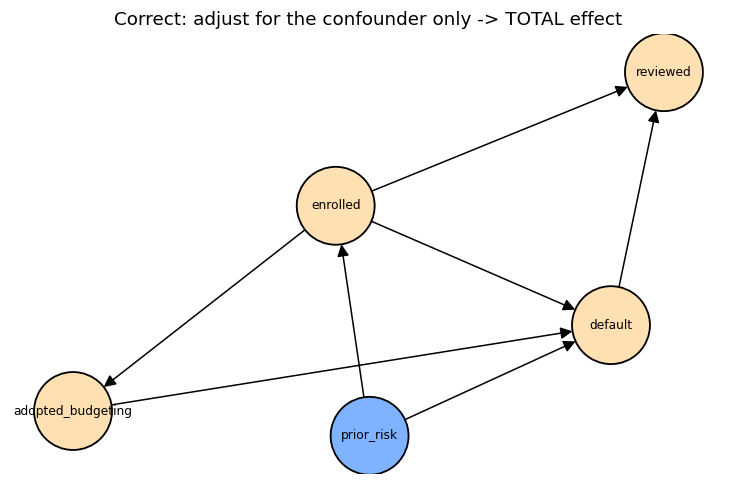

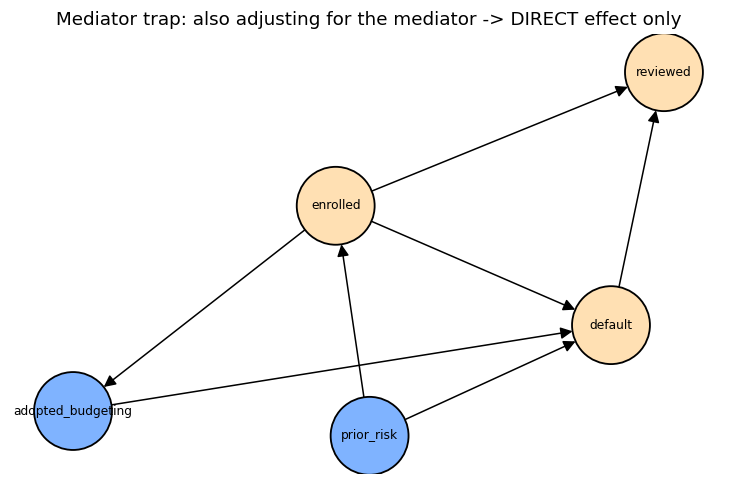

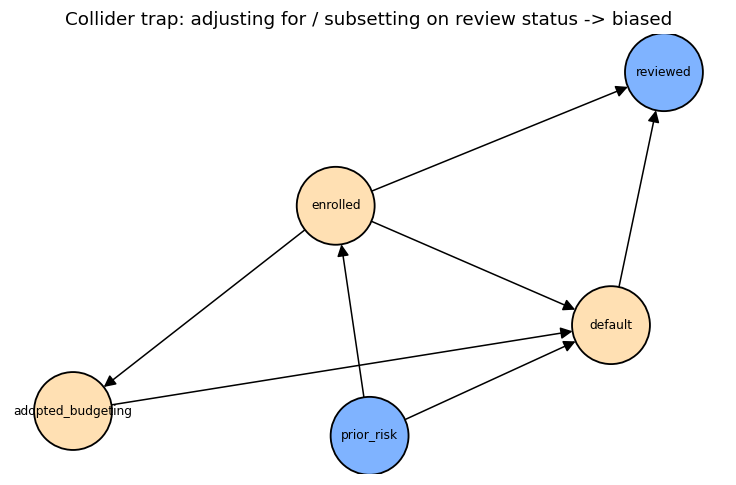

In [13]:

def draw_dag(edges, conditioned=set(), title=""):
    G = nx.DiGraph(edges)
    pos = nx.spring_layout(G, seed=11, k=1.3)
    colors = ["#7fb3ff" if n in conditioned else "#ffe0b3" for n in G.nodes()]
    plt.figure(figsize=(6.5, 4))
    nx.draw(
        G, pos, with_labels=True, node_color=colors, node_size=2600,
        font_size=8, arrowsize=16, edgecolors="black", linewidths=1.2
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

full_edges = [
    ("prior_risk", "enrolled"),
    ("prior_risk", "default"),
    ("enrolled", "adopted_budgeting"),
    ("adopted_budgeting", "default"),
    ("enrolled", "default"),
    ("enrolled", "reviewed"),
    ("default", "reviewed"),
]

draw_dag(full_edges, conditioned={"prior_risk"},
         title="Correct: adjust for the confounder only -> TOTAL effect")
draw_dag(full_edges, conditioned={"prior_risk", "adopted_budgeting"},
         title="Mediator trap: also adjusting for the mediator -> DIRECT effect only")
draw_dag(full_edges, conditioned={"prior_risk", "reviewed"},
         title="Collider trap: adjusting for / subsetting on review status -> biased")



## Key takeaways

1. **Confounding bias doesn't always inflate an effect — it can hide or even reverse one.**
   Because the bank targets its riskiest customers for counseling, the naive comparison made a
   genuinely helpful program look neutral-to-harmful. Always ask *who gets assigned treatment
   and why* before trusting a raw comparison.
2. **Not every "extra variable to control for" is a confounder.** `adopted_budgeting` sits *on*
   the causal path, not upstream of it. Controlling for a mediator answers a different, narrower
   question (the *direct* effect) — useful in some contexts, but the wrong answer if you want
   the *total* effect of the treatment.
3. **Selection bias from restricting to a reviewed/audited/verified subgroup is a collider
   trap**, structurally identical to conditioning on survey responses. It's easy to introduce
   by accident ("let's just use the clean, reviewed data") and — just like the book stresses —
   it survives even perfect randomization of the treatment.
4. **Simulating potential outcomes** (the "godlike powers" trick) is a powerful way to *validate*
   a causal-inference pipeline before trusting it on real data: bake in a known effect, then
   check whether your adjustment strategy recovers it.

### Suggested extensions
- Replace the linear-probability regressions with **logistic regression** and report effects as
  odds ratios / marginal effects — more standard for a real credit-risk setting.
- Add a genuinely **unobserved confounder** (e.g., "customer's underlying financial discipline")
  that drives both enrollment and default, and see how much residual bias remains even after
  adjusting for `prior_risk` — then explore a **surrogate confounder** (e.g., savings-account
  balance trend) as a partial fix.
- Extend the **default outcome to multiple periods** (12/24/36 months), and show — as in the
  book's loan-survival-analysis sidebar — that only the near-term effect is cleanly identifiable
  once customers start dropping out (paying off, defaulting) over time.
